# 5 - AM SDR Demod (IQ/Magnitude)

SDR-Capture/Replay, danach IQ-Demodulation mit lokalem LO und Magnitude.

### In dieser Übung wird eine SDR-Aufzeichnung eines ASK-modulierten Trägersignals eingelesen, demoduliert und analysiert.

- Schätze die Trägerfrequenz, und konfiguriere die LO-Frequenz, um das Signal in die Nähe von Null Hertz zu verschieben.
- 

In [1]:
import json
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().resolve()))

# Interaktive Slider wie in 2-fpc1500-NA-S21: ipympl nutzen (pip install ipympl)
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "widget")
except Exception:
    pass

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Audio, display

from lib.plot_style import apply_lab_matplotlib_style

apply_lab_matplotlib_style()


In [2]:
# Parameter
CENTER_FREQ_HZ = 434.1e6
SAMPLE_RATE_HZ = 2.048e6
GAIN_DB = 20.0
TOTAL_SAMPLES = 262_144*4

REPLAY = True
REPLAY_FILE = Path('recordings') / 'am_sdr_replay.json'

# Fallback-IF fuer synthetisches Testsignal (nur wenn kein RTL-SDR verfuegbar)
f_if_fallback_hz = 0.0

# Globale Peak-/LO-Konfiguration fuer IF-Schaetzung
SEARCH_F_MIN_HZ = 1_000.0
SEARCH_F_MAX_HZ = 150_000.0   # Schutzfenster: nur in diesem IF-Bereich suchen
DC_GUARD_MIN_HZ = 500.0
F_LO_OFFSET_HZ = 500.0        # kleiner Offset, damit Low-IF sichtbar bleibt

# Optionale FFT-Fensterung gegen Leakage
USE_FFT_WINDOW = True
FFT_WINDOW_KIND = 'hann'  # 'hann' | 'hamming' | 'rect'


In [3]:
from lib.replay_iq import load_replay_am_sdr_v1, save_replay_am_sdr_v1
from lib.rtlsdr_helpers import capture_iq_or_fallback

# Capture oder Replay
if REPLAY and REPLAY_FILE.exists():
    iq = load_replay_am_sdr_v1(REPLAY_FILE)
    print('Replay-IQ geladen:', REPLAY_FILE)
else:
    iq = capture_iq_or_fallback(
        CENTER_FREQ_HZ,
        SAMPLE_RATE_HZ,
        GAIN_DB,
        TOTAL_SAMPLES,
        f_if_fallback_hz=f_if_fallback_hz,
    )
    save_replay_am_sdr_v1(
        REPLAY_FILE,
        iq,
        sample_rate_hz=SAMPLE_RATE_HZ,
        center_freq_hz=CENTER_FREQ_HZ,
        gain_db=GAIN_DB,
    )
    print('Replay-IQ gespeichert:', REPLAY_FILE)

if iq.size < TOTAL_SAMPLES:
    raise RuntimeError(f'Zu wenige Samples: {iq.size} < {TOTAL_SAMPLES}')
iq = iq[:TOTAL_SAMPLES].astype(np.complex64)
fs = float(SAMPLE_RATE_HZ)
t = np.arange(len(iq)) / fs

Replay-IQ geladen: recordings\am_sdr_replay.json


## ToDo: 
- Abschätzen der Trägerfrequenz und konfigurieren der LO frequenz f_if_est_hz, sodass Signal in die Nähe Null Hertz verschoben wird.

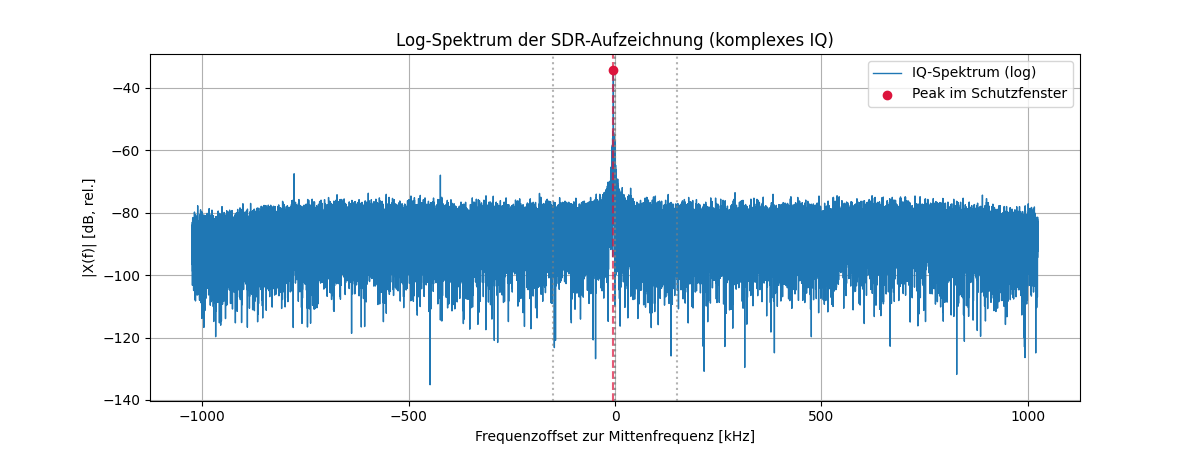

Peak-Frequenz (IF-Schätzung): -4000.0 Hz
Schutzfenster: 1000.0 .. 150000.0 Hz
Gewähltes f_lo: -500.0 Hz (Offset 500.0 Hz)


In [4]:
# LO aus Peak schätzen (kleiner Offset, damit Low-IF sichtbar bleibt)
f_if_est_hz = 0  # HIER Eingabe der geschätzen Trägerfrequenz.
f_lo = f_if_est_hz - F_LO_OFFSET_HZ     # wir behalten uns einen kleinen Frequenzfehler für Demonstrationszwecke.

# Zweiseitiges Log-Spektrum direkt nach dem Einlesen (komplexes IQ) + IF-Peak-Schätzung
N_fft_spec = 16384*4
x_spec = iq[:N_fft_spec]
if USE_FFT_WINDOW:
    if FFT_WINDOW_KIND == 'hann':
        w_spec = np.hanning(N_fft_spec)
    elif FFT_WINDOW_KIND == 'hamming':
        w_spec = np.hamming(N_fft_spec)
    else:
        w_spec = np.ones(N_fft_spec)
else:
    w_spec = np.ones(N_fft_spec)

cg_spec = np.mean(w_spec)
X_spec = np.fft.fftshift(np.fft.fft(x_spec * w_spec, n=N_fft_spec))
f_spec = np.fft.fftshift(np.fft.fftfreq(N_fft_spec, d=1/fs))
A_spec = np.abs(X_spec) / (N_fft_spec * max(cg_spec, 1e-12))
S_db = 20*np.log10(np.maximum(A_spec, 1e-12))

# Peak-Suche mit symmetrischem Schutzfenster um 0 Hz (Störer außerhalb ignorieren)
dc_guard_hz = max(DC_GUARD_MIN_HZ, fs / N_fft_spec)

# Symmetrisch: SEARCH_F_MIN_HZ <= |f| <= SEARCH_F_MAX_HZ
peak_mask = (
    (np.abs(f_spec) >= max(dc_guard_hz, SEARCH_F_MIN_HZ))
    & (np.abs(f_spec) <= SEARCH_F_MAX_HZ)
)

if not np.any(peak_mask):
    raise RuntimeError('Peak-Suchfenster ist leer. Prüfe SEARCH_F_MIN_HZ/SEARCH_F_MAX_HZ.')

idx_peak = np.argmax(A_spec[peak_mask])
peak_f_hz = float(f_spec[peak_mask][idx_peak])
peak_a = float(A_spec[peak_mask][idx_peak])



plt.figure(figsize=(12, 4.5))
plt.plot(f_spec/1e3, S_db, lw=1.0, label='IQ-Spektrum (log)')
plt.scatter([peak_f_hz/1e3], [20*np.log10(max(peak_a,1e-12))], color='crimson', zorder=4, label='Peak im Schutzfenster')
plt.axvline(peak_f_hz/1e3, color='crimson', ls='--', alpha=0.7)
plt.axvline( SEARCH_F_MIN_HZ/1e3, color='gray', ls=':', alpha=0.6)
plt.axvline( SEARCH_F_MAX_HZ/1e3, color='gray', ls=':', alpha=0.6)
plt.axvline(-SEARCH_F_MIN_HZ/1e3, color='gray', ls=':', alpha=0.6)
plt.axvline(-SEARCH_F_MAX_HZ/1e3, color='gray', ls=':', alpha=0.6)
plt.title('Log-Spektrum der SDR-Aufzeichnung (komplexes IQ)')
plt.xlabel('Frequenzoffset zur Mittenfrequenz [kHz]')
plt.ylabel('|X(f)| [dB, rel.]')
plt.legend()
plt.show()

print(f'Peak-Frequenz (IF-Schätzung): {peak_f_hz:.1f} Hz')
print(f'Schutzfenster: {SEARCH_F_MIN_HZ:.1f} .. {SEARCH_F_MAX_HZ:.1f} Hz')
print(f'Gewähltes f_lo: {f_lo:.1f} Hz (Offset {F_LO_OFFSET_HZ:.1f} Hz)')

## ToDo:

- Eingabe der Filterbandbreite f_lp für den Sliding Averager als Basisbandfilter, ermittle einen sinnvollen Wert (bis ma. 40kHz) 

In [5]:
# IQ-Demodulation mit lokalem LO (aus Spektrum geschätzt)
lo_i = np.exp(-1j * 2*np.pi * f_lo * t).astype(np.complex64)
z = iq * lo_i

I_raw = np.real(z).astype(np.float64)
Q_raw = np.imag(z).astype(np.float64)

f_lp = 25_000.0   # HIER Filterbandbreite spezifizieren
N_win = max(3, int(round(fs / max(1.0, f_lp))))
if N_win % 2 == 0:
    N_win += 1
h = np.ones(N_win, dtype=np.float64) / N_win

I = np.convolve(I_raw, h, mode='same')
Q = np.convolve(Q_raw, h, mode='same')
u_mag = np.sqrt(I**2 + Q**2)
u_demod = u_mag - np.mean(u_mag)
print(f'f_lo={f_lo:.1f} Hz, N_win={N_win}')

f_lo=-500.0 Hz, N_win=83


## Plot der IQ-Basebandsignale und des demodulierten Signals

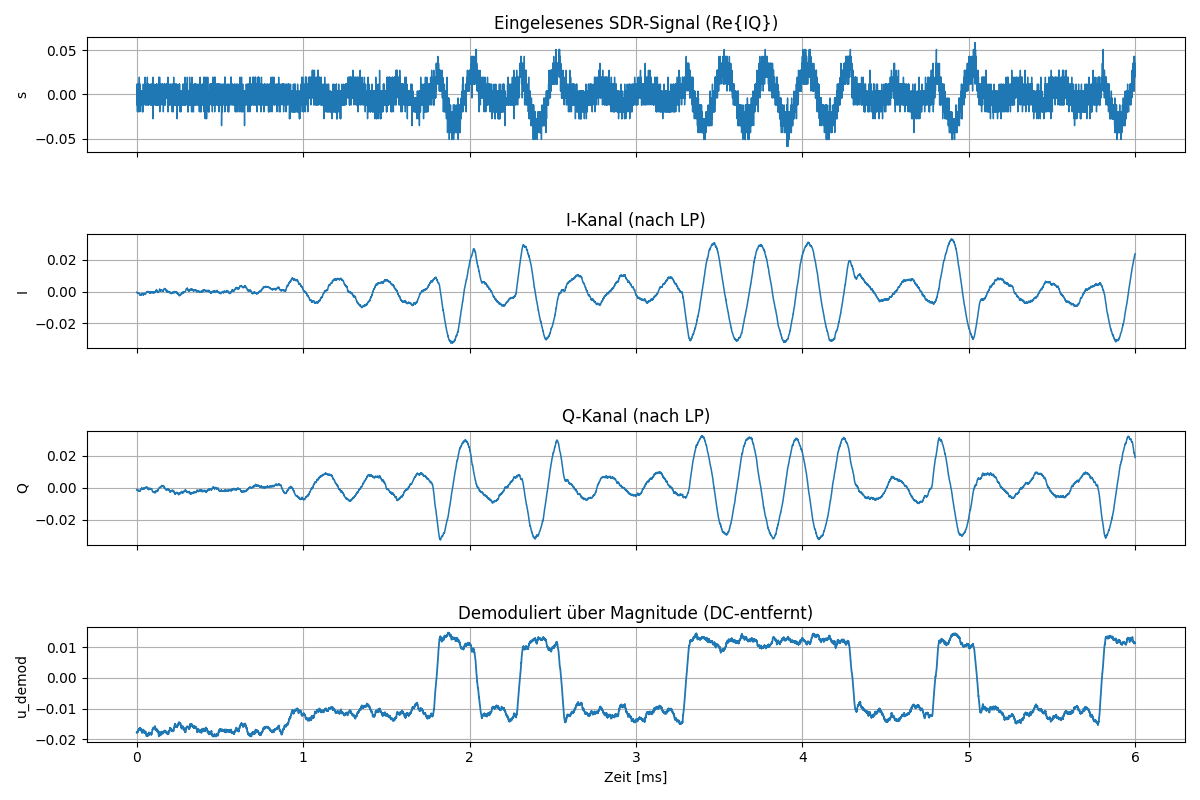

In [6]:
# Plots: Signal, I/Q, Demod
s_real = np.real(iq).astype(np.float64)
t_plot_ms = 6.0
n_plot = min(len(iq), int(t_plot_ms*1e-3*fs))

fig, ax = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
ax[0].plot(t[:n_plot]*1e3, s_real[:n_plot], lw=1.0)
ax[0].set_title('Eingelesenes SDR-Signal (Re{IQ})')
ax[0].set_ylabel('s')

ax[1].plot(t[:n_plot]*1e3, I[:n_plot], lw=1.1)
ax[1].set_title('I-Kanal (nach LP)')
ax[1].set_ylabel('I')

ax[2].plot(t[:n_plot]*1e3, Q[:n_plot], lw=1.1)
ax[2].set_title('Q-Kanal (nach LP)')
ax[2].set_ylabel('Q')

ax[3].plot(t[:n_plot]*1e3, u_demod[:n_plot], lw=1.3)
ax[3].set_title('Demoduliert über Magnitude (DC-entfernt)')
ax[3].set_ylabel('u_demod')
ax[3].set_xlabel('Zeit [ms]')
plt.tight_layout(); plt.show()

In [7]:
# (Info) Log-Spektrum + Peak-Schätzung wurde bereits direkt nach dem Einlesen gezeigt.
pass

## Spektrum des Zero-IF Basisbandsignals vor dem Baseband-Filter

### ToDo:

- Aus diesem Spektrum soll die Bitrate ermittelt werden.
- Hinweis: diese Bitrate wird durch das Testsignal bestimmt, welches live gesendet und aufgezeichnet wurde, die Bitrate ist ein Vielfahces von 100Hz.

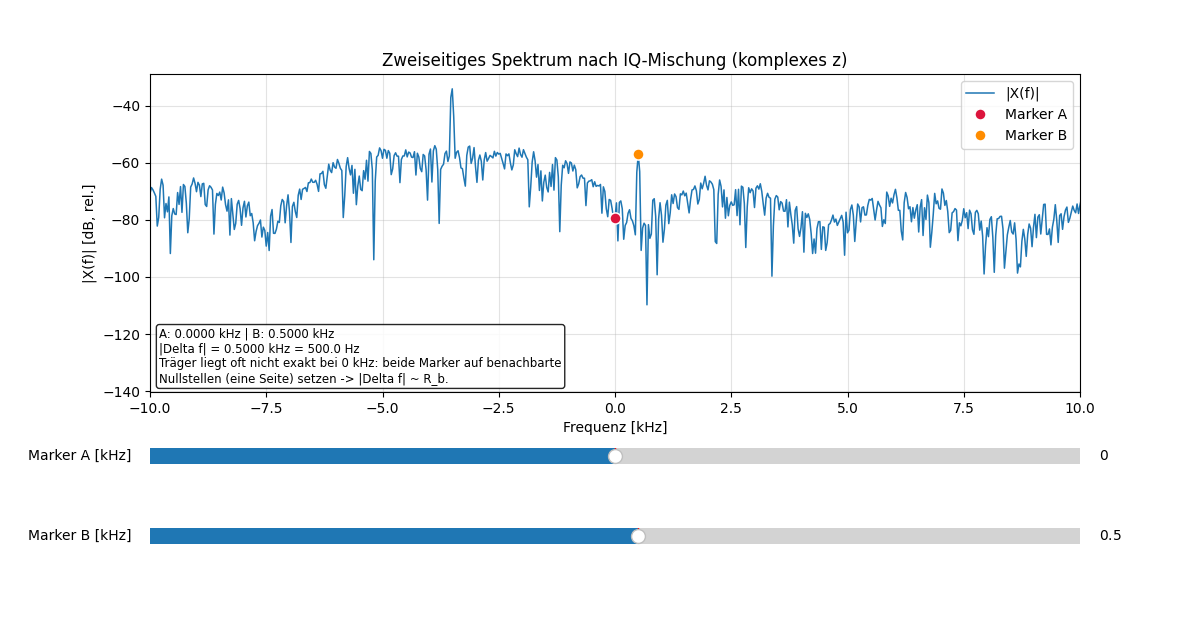

In [8]:
# Zweiseitiges Spektrum nach Mischung (Low-IF sichtbar) ueber komplexes Basisbandsignal z
N_fft = 16384*4
x = np.zeros(N_fft, dtype=np.complex128)
n_copy = min(len(z), N_fft)
x[:n_copy] = z[:n_copy]
if USE_FFT_WINDOW:
    if FFT_WINDOW_KIND == 'hann':
        w = np.hanning(N_fft)
    elif FFT_WINDOW_KIND == 'hamming':
        w = np.hamming(N_fft)
    else:
        w = np.ones(N_fft)
else:
    w = np.ones(N_fft)

cg = np.mean(w)
X = np.fft.fftshift(np.fft.fft(x * w, n=N_fft))
f = np.fft.fftshift(np.fft.fftfreq(N_fft, d=1/fs))
A = np.abs(X) / (N_fft * max(cg, 1e-12))
A_db = 20*np.log10(np.maximum(A, 1e-12))

f_khz = f / 1e3

SPEC_KHZ_MIN = -10.0
SPEC_KHZ_MAX = 10.0

plt.close("spectrum_z_marker")
fig = plt.figure(figsize=(12, 6.2), num="spectrum_z_marker")
gs = fig.add_gridspec(3, 1, height_ratios=[1.0, 0.10, 0.10], hspace=0.38)
ax = fig.add_subplot(gs[0, 0])
ax_slider_a = fig.add_subplot(gs[1, 0])
ax_slider_b = fig.add_subplot(gs[2, 0])

ax.plot(f_khz, A_db, lw=1.1, label="|X(f)|")
ax.set_xlim(SPEC_KHZ_MIN, SPEC_KHZ_MAX)
ax.set_title("Zweiseitiges Spektrum nach IQ-Mischung (komplexes z)")
ax.set_xlabel("Frequenz [kHz]")
ax.set_ylabel("|X(f)| [dB, rel.]")
ax.grid(True, alpha=0.35)


def _db_at_khz(fq_khz: float) -> float:
    # dB-Wert des Spektrums bei fq_khz (linear interpoliert)
    fk = float(np.clip(fq_khz, SPEC_KHZ_MIN, SPEC_KHZ_MAX))
    return float(np.interp(fk, f_khz, A_db))


xa0, xb0 = 0.0, 0.5
(marker_a,) = ax.plot(
    [xa0],
    [_db_at_khz(xa0)],
    marker="o",
    ms=8,
    color="crimson",
    mec="white",
    mew=1.1,
    ls="none",
    zorder=7,
    label="Marker A",
)
(marker_b,) = ax.plot(
    [xb0],
    [_db_at_khz(xb0)],
    marker="o",
    ms=8,
    color="darkorange",
    mec="white",
    mew=1.1,
    ls="none",
    zorder=7,
    label="Marker B",
)
ax.legend(loc="upper right")

info_text = ax.text(
    0.01,
    0.02,
    "",
    transform=ax.transAxes,
    fontsize=8.5,
    ha="left",
    va="bottom",
    bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.85),
)

from matplotlib.widgets import Slider

slider_a = Slider(
    ax=ax_slider_a,
    label="Marker A [kHz]",
    valmin=SPEC_KHZ_MIN,
    valmax=SPEC_KHZ_MAX,
    valinit=0.0,
)
slider_b = Slider(
    ax=ax_slider_b,
    label="Marker B [kHz]",
    valmin=SPEC_KHZ_MIN,
    valmax=SPEC_KHZ_MAX,
    valinit=0.5,
)


def update_markers(_val=None):
    xa = float(slider_a.val)
    xb = float(slider_b.val)
    marker_a.set_data([xa], [_db_at_khz(xa)])
    marker_b.set_data([xb], [_db_at_khz(xb)])
    df_khz = abs(xb - xa)
    df_hz = df_khz * 1000.0
    info_text.set_text(
        f"A: {xa:.4f} kHz | B: {xb:.4f} kHz\n"
        f"|Delta f| = {df_khz:.4f} kHz = {df_hz:.1f} Hz\n"
        "Träger liegt oft nicht exakt bei 0 kHz: beide Marker auf benachbarte\n"
        "Nullstellen (eine Seite) setzen -> |Delta f| ~ R_b."
    )
    fig.canvas.draw_idle()


slider_a.on_changed(update_markers)
slider_b.on_changed(update_markers)
update_markers()
plt.show()


## ToDo:
- Eingabe der geschätzten Bitrate, damit ein Augendiagramm und Amplitudenhistogramm für die Bit-Abtastwerte möglich wird.
- Nachdem die Bitrate nur näherungsweise aus dem Baseband-Spektrum ermittelt werden kann, wurde sie auf ein exakte Vielfaches von 100Hz festgelegt.

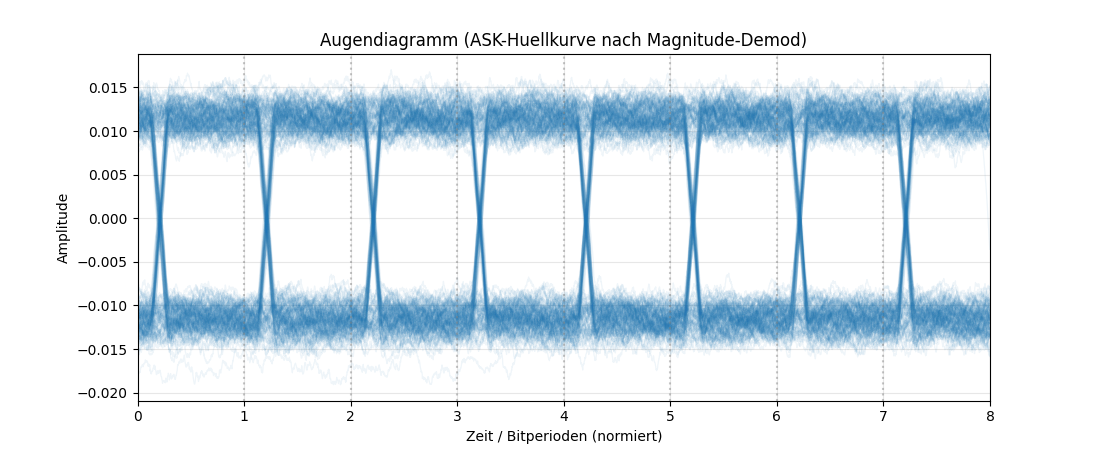

Sample Rate=2048000.0,  SAMPLES_PER_BIT=512, NUM_BITS_IN_EYE_PLOT=8, implizite Bitrate ~ 4000.0 bit/s


In [9]:
# Augendiagramm nach Demodulation (Huellkurve u_demod)
from lib.eye_diagram import plot_eye_diagram

# === Experimentierparameter ===
# Bitlaenge in Samples: entweder direkt (z. B. SAMPLES_PER_BIT = 2048) oder aus Bitrate:
BITRATE_ASSUMED_HZ = 4000.0
SAMPLES_PER_BIT = max(1, int(round(fs / BITRATE_ASSUMED_HZ)))
NUM_BITS_IN_EYE_PLOT = 8   # horizontale Symbolperioden im Plot ("Augen" / Bits sichtbar)
EYE_START_OFFSET = 0       # Fenster-Raster: bei Bedarf 0 .. SAMPLES_PER_BIT-1 durchprobieren (Raster zu Bitgrenzen)
EYE_MAX_TRACES = 450

plot_eye_diagram(
    u_demod,
    samples_per_bit=SAMPLES_PER_BIT,
    num_bits_visible=NUM_BITS_IN_EYE_PLOT,
    start_offset=EYE_START_OFFSET,
    max_traces=EYE_MAX_TRACES,
    title="Augendiagramm (ASK-Huellkurve nach Magnitude-Demod)",
)
plt.show()

print(
    f"Sample Rate={fs},  "
    f"SAMPLES_PER_BIT={SAMPLES_PER_BIT}, NUM_BITS_IN_EYE_PLOT={NUM_BITS_IN_EYE_PLOT}, "
    f"implizite Bitrate ~ {fs / SAMPLES_PER_BIT:.1f} bit/s"
)


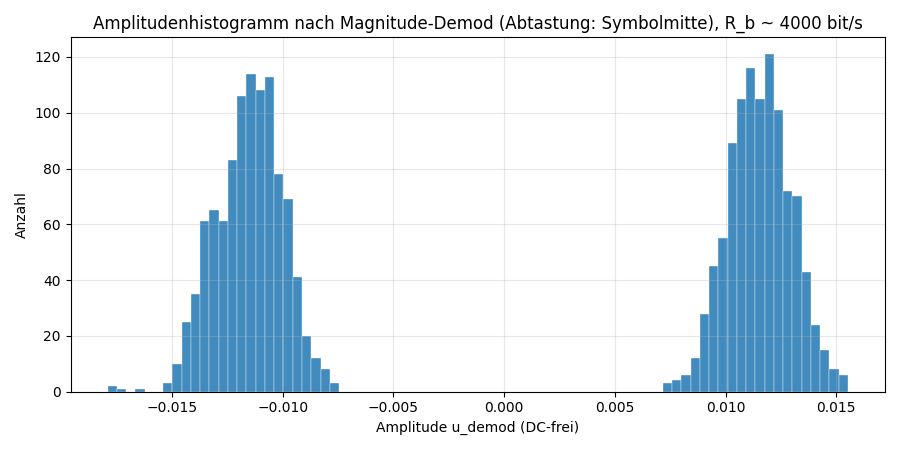

HIST_SYMBOL_CENTER_ONLY=True, N=2047, SAMPLES_PER_BIT=512


In [10]:
# Amplitudenhistogramm der demodulierten Hüllkurve (DC-frei: u_demod)
# Zeigt die Überlagerung der beiden ASK-Pegel + Rauschen (AWGN im Funkkanal wirkt hier
# nach Demodulation u.a. als Streuung der Amplituden). Ohne exakte Taktsynchronisation
# sind Symbolmittelpunkte trotzdem oft brauchbar (gleiche Annahme wie Augendiagramm).

BITRATE_ASSUMED_HZ = 4000.0
SAMPLES_PER_BIT = max(1, int(round(fs / BITRATE_ASSUMED_HZ)))

# True: nur Samples in Bitmitte (eine Stützstelle pro Symbol) -> klarere Zwei-Peaks-Struktur
# False: alle Samples -> Übergänge/Ripple, Histogramm breiter
HIST_SYMBOL_CENTER_ONLY = True

# Bit-Raster relativ zu u_demod[0]: Sample-Index, an dem Bit 0 *beginnt* (SDR-Start ist typisch
# nicht bit-synchron). Typisch 0 .. SAMPLES_PER_BIT-1; groessere Werte werden modulo
# SAMPLES_PER_BIT genommen (gleiche Phasenlage). Empfohlen: gleicher Wert wie EYE_START_OFFSET.
BIT_START_OFFSET_SAMPLES = 0

HIST_BINS = 80

N_sig = u_demod.size
if HIST_SYMBOL_CENTER_ONLY:
    spb = max(SAMPLES_PER_BIT, 1)
    off = int(BIT_START_OFFSET_SAMPLES) % spb
    first_center = off + spb // 2
    if first_center < 0 or first_center >= N_sig:
        raise RuntimeError(
            "BIT_START_OFFSET_SAMPLES ungueltig: erster Symbolindex ausserhalb des Signals."
        )
    n_bits = (N_sig - 1 - first_center) // spb + 1
    if n_bits < 2:
        raise RuntimeError(
            "Zu wenig Daten fuer Histogramm - Bitrate/SAMPLES_PER_BIT/BIT_START_OFFSET pruefen."
        )
    sample_idx = first_center + np.arange(n_bits) * spb
    sample_idx = np.clip(sample_idx, 0, N_sig - 1)
    u_hist = u_demod[sample_idx].astype(np.float64)
    hist_subtitle = "Abtastung: Symbolmitte"
else:
    u_hist = u_demod.astype(np.float64)
    hist_subtitle = "alle Samples"

fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.hist(u_hist, bins=HIST_BINS, color="C0", alpha=0.85, edgecolor="white", linewidth=0.3)
ax.set_title(
    f"Amplitudenhistogramm nach Magnitude-Demod ({hist_subtitle}), "
    f"R_b ~ {BITRATE_ASSUMED_HZ:g} bit/s"
)
ax.set_xlabel("Amplitude u_demod (DC-frei)")
ax.set_ylabel("Anzahl")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f"HIST_SYMBOL_CENTER_ONLY={HIST_SYMBOL_CENTER_ONLY}, N={u_hist.size}, "
    f"SAMPLES_PER_BIT={SAMPLES_PER_BIT}, BIT_START_OFFSET_SAMPLES={BIT_START_OFFSET_SAMPLES}"
)


### Hinweis: Symbolmitten fürs Amplitudenhistogramm

**Wird das aus den Daten automatisch gefunden?** Nein: In diesem Block gibt es keinen
Taktrückgewinn (keine Schätzung der optimalen Abtastphase aus dem Signal selbst). Stattdessen
wird eine **Bitrate-Annahme** in die Sample-Rechnung übersetzt.

**Bit-Start-Offset:** Zusaetzlich kann `BIT_START_OFFSET_SAMPLES` gesetzt werden: das ist der
Sample-Index, an dem **Bit 0 beginnt** (relativ zu `u_demod[0]`). Damit laesst sich das
Abtastraster an den tatsaechlichen Funk-/SDR-Start anpassen. Werte ausserhalb
`0 .. SAMPLES_PER_BIT-1` sind modulo `SAMPLES_PER_BIT` aequivalent. Empfohlen: gleicher Wert
wie `EYE_START_OFFSET` im Augendiagramm.

**Vorgehen im Code:** Aus `fs` und `BITRATE_ASSUMED_HZ` wird `SAMPLES_PER_BIT = round(fs / R_b)`
berechnet. Bei `HIST_SYMBOL_CENTER_ONLY = True` wird pro Bit genau **ein** Abtastwert in der
**Mitte** des zugehörigen Sample-Blocks verwendet:
`k * SAMPLES_PER_BIT + SAMPLES_PER_BIT // 2` mit `k = 0 ... n_bits-1` (geclippt auf gültige Indizes).
Damit liegt die Abtastung implizit auf einem **Raster aus gleich langen Bitintervallen**, das
bei Sample **0** startet. Bei `HIST_SYMBOL_CENTER_ONLY = False` gehen **alle** Samples ins
Histogramm; Übergänge und Ripple überlagern sich dann und die zwei Pegel sind weniger klar getrennt.

**Manuell anpassen:** Bitrate über **`BITRATE_ASSUMED_HZ`** (oder direkt `SAMPLES_PER_BIT`).
Den **Phasen-Offset** des Bit-Rasters relativ zum SDR-Start setzt man über **`BIT_START_OFFSET_SAMPLES`**.
Fuer konsistentes Auge vs. Histogramm: denselben Wert wie **`EYE_START_OFFSET`** verwenden.


## SNR grob aus dem Amplitudenhistogramm schätzen

Nach Demodulation und DC-Entzug liegen die **Amplituden in den Symbolmittelpunkten** (und
in guter Näherung auch alle Samples) als **Überlagerung zweier „Haufen“** vor: je ein
**Gauß-ähnlicher Cluster** um den niedrigen und den hohen ASK-Pegel. Das **additive
Rauschen** (z. B. AWGN im Kanal, nach Bandbegrenzung und Demodulation weiterhin oft
gaußförmig näherungsweise) **verbreitert** diese Haufen; der **Abstand der Mittelwerte**
$\mu_{\mathrm{lo}}$ und $\mu_{\mathrm{hi}}$ ist die **Pegeltrennung**, die **Streuung**
innerhalb der Haufen schätzt die **Rauschvarianz** $\sigma^2$.

**Schätzidee:** Zwei Mittelwerte $\hat\mu_{\mathrm{lo}}$, $\hat\mu_{\mathrm{hi}}$ und eine
gemeinsame Rausch-Streuung $\hat\sigma$ bestimmen, dann eine **lineare SNR** definieren, die
zur **Fehlerwahrscheinlichkeit** beim Schwellenentscheid passend skaliert ist:

$$
\mathrm{SNR}_{\mathrm{lin}} \approx \frac{\bigl(\hat\mu_{\mathrm{hi}} - \hat\mu_{\mathrm{lo}}\bigr)^2}{4\,\hat\sigma^2}
\qquad\text{bzw.}\qquad
\mathrm{SNR}_{\mathrm{dB}} = 10\log_{10}(\mathrm{SNR}_{\mathrm{lin}}).
$$

Der Faktor $4$ im Nenner entspricht der üblichen **Detektions-SNR** bei binärer Entscheidung
mit Abstand $|\mu_{\mathrm{hi}}-\mu_{\mathrm{lo}}|$ und Rauschen der Varianz $\sigma^2$
(Schwelle in der Mitte; Argument der $Q$-Funktion proportional $|\Delta\mu|/(2\sigma)$).

**Didaktik — welches Verfahren?**

- **K-Means mit $k=2$ (1D)** auf den Amplitudenwerten, danach **Stichprobenmittel und
  -varianz** je Cluster: sehr **anschaulich** („zwei Schwerpunkte = zwei Pegel“), wenig
  Mathematik, **ohne** Zusatzpakete. Das ist hier implementiert.
- **Gauß-Mischverteilung + EM** (z. B. zwei Komponenten): **modelliert explizit** „zwei
  Gaußkurven“ — theoretisch sauber, für eine Vorlesung ideal; in der Praxis oft über
  `sklearn.mixture.GaussianMixture`. Ergebnis ähnlich, wenn die Verteilung gut zweigipflig ist.

Hinweis: Ohne exakte **Takt-/Phasensynchronisation** oder bei **Histogramm über alle
Samples** sind die Cluster **verwaschen**; die Schätzung wird **optimistisch oder
pessimistisch** — sie ist eine **Groborientierung**, kein Ersatz für kalibrierte
Messungen.


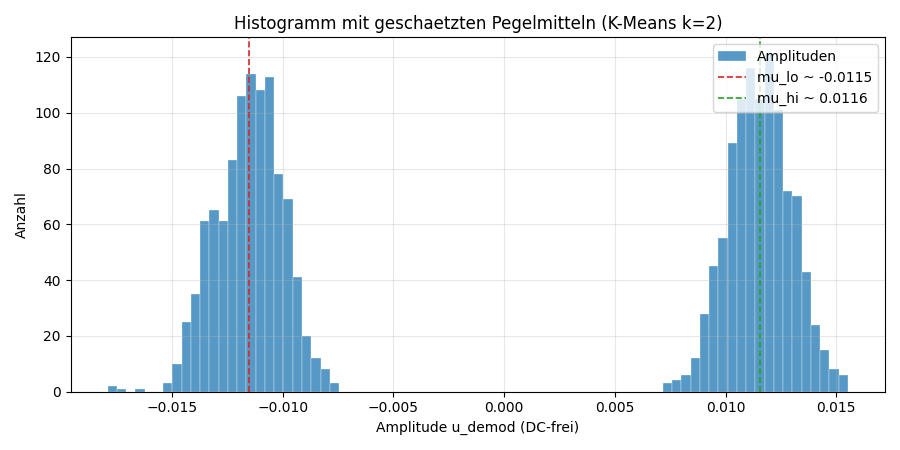

Pegelabstand |mu_hi-mu_lo| = 0.02308,  pooled sigma ~ 0.00146
SNR_lin ~ 62.472  (17.96 dB)  (Symbolmitte=True, N=2047)


In [11]:
# SNR grob aus den Histogramm-Daten (K-Means k=2 + Momenten pro Cluster)
# Gleiche Annahmen wie Histogramm-Zelle - bei Abweichung hier anpassen.
BITRATE_ASSUMED_HZ = 4000.0
SAMPLES_PER_BIT = max(1, int(round(fs / BITRATE_ASSUMED_HZ)))
HIST_SYMBOL_CENTER_ONLY = True  # wie in der Histogramm-Zelle
BIT_START_OFFSET_SAMPLES = int(globals().get("BIT_START_OFFSET_SAMPLES", 0))

N_sig = u_demod.size
if HIST_SYMBOL_CENTER_ONLY:
    spb = max(SAMPLES_PER_BIT, 1)
    off = int(BIT_START_OFFSET_SAMPLES) % spb
    first_center = off + spb // 2
    if first_center < 0 or first_center >= N_sig:
        raise RuntimeError("BIT_START_OFFSET_SAMPLES ungueltig fuer SNR-Zelle.")
    n_bits = (N_sig - 1 - first_center) // spb + 1
    if n_bits < 2:
        raise RuntimeError("Zu wenig Daten fuer SNR-Schaetzung.")
    sample_idx = first_center + np.arange(n_bits) * spb
    sample_idx = np.clip(sample_idx, 0, N_sig - 1)
    u_snr = u_demod[sample_idx].astype(np.float64)
else:
    u_snr = u_demod.astype(np.float64)

def kmeans_1d_k2(x: np.ndarray, max_iter: int = 80) -> tuple[np.ndarray, np.ndarray]:
    # Zwei Clusterzentren; Zuordnung per naechstem Zentrum.
    x = np.asarray(x, dtype=np.float64).ravel()
    lo, hi = np.percentile(x, [25.0, 75.0])
    if not np.isfinite(lo) or not np.isfinite(hi) or lo >= hi:
        lo, hi = float(np.min(x)), float(np.max(x))
    c = np.array([lo, hi], dtype=np.float64)
    for _ in range(max_iter):
        d0 = (x - c[0]) ** 2
        d1 = (x - c[1]) ** 2
        lbl = d0 < d1
        n0 = int(np.sum(lbl))
        n1 = x.size - n0
        if n0 == 0 or n1 == 0:
            break
        new_c = np.array([x[lbl].mean(), x[~lbl].mean()], dtype=np.float64)
        if np.max(np.abs(new_c - c)) < 1e-12 * (np.max(np.abs(c)) + 1.0):
            break
        c = new_c
    d0 = (x - c[0]) ** 2
    d1 = (x - c[1]) ** 2
    lbl = d0 < d1
    return c, lbl


centers, lbl = kmeans_1d_k2(u_snr)
order = np.argsort(centers)
mu_lo, mu_hi = float(centers[order[0]]), float(centers[order[1]])
# lbl True = nahe centers[0]; nach Sortierung umlabeln
c_lo, c_hi = centers[order[0]], centers[order[1]]
lbl_lo = np.abs(u_snr - c_lo) <= np.abs(u_snr - c_hi)

sig_lo = float(np.std(u_snr[lbl_lo], ddof=1)) if np.sum(lbl_lo) > 1 else 0.0
sig_hi = float(np.std(u_snr[~lbl_lo], ddof=1)) if np.sum(~lbl_lo) > 1 else 0.0
sigma_pooled = float(np.sqrt((sig_lo**2 + sig_hi**2) / 2.0 + 1e-30))

d = mu_hi - mu_lo
snr_lin = (d * d) / (4.0 * sigma_pooled * sigma_pooled + 1e-30)
snr_db = 10.0 * np.log10(max(snr_lin, 1e-30))

fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.hist(u_snr, bins=80, color="C0", alpha=0.75, edgecolor="white", linewidth=0.3, label="Amplituden")
ax.axvline(mu_lo, color="C3", ls="--", lw=1.2, label=f"mu_lo ~ {mu_lo:.4f}")
ax.axvline(mu_hi, color="C2", ls="--", lw=1.2, label=f"mu_hi ~ {mu_hi:.4f}")
ax.set_title("Histogramm mit geschaetzten Pegelmitteln (K-Means k=2)")
ax.set_xlabel("Amplitude u_demod (DC-frei)")
ax.set_ylabel("Anzahl")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f"Pegelabstand |mu_hi-mu_lo| = {d:.5f},  pooled sigma ~ {sigma_pooled:.5f}\n"
    f"SNR_lin ~ {snr_lin:.3f}  ({snr_db:.2f} dB)  "
    f"(Symbolmitte={HIST_SYMBOL_CENTER_ONLY}, N={u_snr.size}, offset={BIT_START_OFFSET_SAMPLES})"
)


In [12]:
# Audio (48 kS/s, zyklisch)
fs_audio = 48_000
duration_s = 4.0
t_src = np.arange(len(u_demod)) / fs
n_dst = int(round(len(u_demod) * fs_audio / fs))
t_dst = np.arange(n_dst) / fs_audio
u_audio_base = np.interp(t_dst, t_src, u_demod)
n_target = int(duration_s * fs_audio)
u_audio = np.tile(u_audio_base, int(np.ceil(n_target / len(u_audio_base))))[:n_target]
u_audio = u_audio / max(1e-12, np.max(np.abs(u_audio)))
display(Audio(u_audio, rate=fs_audio))

## ToDo:
- Erstelle ein Blockschaltbild für die gesamte Signalverarbeitungskette, beginnend mit dem Sender (ASK-Modulator), der Funkstrecke, dem SDR und in weiterer Folge der Signalverarbeitung im Notebook, mit einer kurzen Erklärung dieser Fubktionsblöcke und einer Erklärung, was wir aus den gezeigten Plots ablesen können.
- Wie groß ist die Bitrate des ASK-Signals?
- Wie groß ist der Modulationsgrad des ASK-Signals? aus welchem gezeigten Plot kann dieser ermittelt werden?
- - Ermittle den Einfluss der Bandbreite des Basisband-Tiefpassfilters auf das erzielte SNR für 4 verschiedene Grenzfrequenzen bis 40kHz. und erstelle eine tabellarische Übersicht. Kommentiere diese Ergebnisse. 

## Blockschaltbild HIER einfügen.
Syntax für Link aufs Bild: ![Erklärungstext](media\bild.jpg)